# OKCupid Date-A-Scientist: Predicting Zodiac Signs from OKCupid Profiles

## The Problem
Zodiac compatibility is a big deal for a lot of OkCupid users. Analyzing the data in the previous notebook showed that 18.4% of profiles don't have a zodiac sign filled in at all. That's a pretty significant chunk of users who could be getting worse matches just because they skipped that one field (roughly 1 in 5 users!).

## The Goal
The idea is to use machine learning to take a guess at what someone's zodiac sign might be, based on other things we already know about them like their lifestyle, habits, and demographic info.  If we can predict it reasonably well, we can fill in those gaps and potentially improve match quality.

## The Methodology
This seems like a multi-class classification problem. We can use feature, such as drinking habits, smoking, education, age, etc to predict someone's zodiac sign. The model will be trained on profiles where the sign is already known, then we can use the model to predict the ones that are missing. There is no true science to zodiac signs given that they are based on birthdates, but it would be interesting to find if there is a correlation among any features.

---------------------------------------------------------------------------------------

In [57]:
# Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC

from plot_style import set_plot_style
set_plot_style()

# Load Data

In [10]:
df = pd.read_csv("data/profiles.csv")
print(f"Dataset shape: {df.shape}")
print(f"Dataset columns: {df.columns.tolist()}")

Dataset shape: (59946, 31)
Dataset columns: ['age', 'body_type', 'diet', 'drinks', 'drugs', 'education', 'essay0', 'essay1', 'essay2', 'essay3', 'essay4', 'essay5', 'essay6', 'essay7', 'essay8', 'essay9', 'ethnicity', 'height', 'income', 'job', 'last_online', 'location', 'offspring', 'orientation', 'pets', 'religion', 'sex', 'sign', 'smokes', 'speaks', 'status']


# Preprocess Data

In [11]:
df["sign"].value_counts(dropna=False)

sign
NaN                                              11056
gemini and it&rsquo;s fun to think about          1782
scorpio and it&rsquo;s fun to think about         1772
leo and it&rsquo;s fun to think about             1692
libra and it&rsquo;s fun to think about           1649
taurus and it&rsquo;s fun to think about          1640
cancer and it&rsquo;s fun to think about          1597
pisces and it&rsquo;s fun to think about          1592
sagittarius and it&rsquo;s fun to think about     1583
virgo and it&rsquo;s fun to think about           1574
aries and it&rsquo;s fun to think about           1573
aquarius and it&rsquo;s fun to think about        1503
virgo but it doesn&rsquo;t matter                 1497
leo but it doesn&rsquo;t matter                   1457
cancer but it doesn&rsquo;t matter                1454
gemini but it doesn&rsquo;t matter                1453
taurus but it doesn&rsquo;t matter                1450
aquarius but it doesn&rsquo;t matter              1408
libra

In [12]:
df["sign_cleaned"] =df["sign"].str.extract(r"([A-Za-z]+)")[0].str.lower()

print(f"Unique signs after cleaning: {df['sign_cleaned'].dropna().unique()}")
print(f"Rows with missing sign: {df['sign_cleaned'].isnull().sum()}")
print(f"Rows without missing sign: {df['sign_cleaned'].notnull().sum()}")

Unique signs after cleaning: <ArrowStringArray>
[     'gemini',      'cancer',      'pisces',    'aquarius',      'taurus',
       'virgo', 'sagittarius',         'leo',       'aries',       'libra',
     'scorpio',   'capricorn']
Length: 12, dtype: str
Rows with missing sign: 11056
Rows without missing sign: 48890


In [17]:
results = []

for col in ['drinks', 'smokes', 'drugs', 'body_type', 'education']:
    vc = df[col].value_counts().dropna().reset_index()
    vc.columns = [col, f'{col}_count']
    results.append(vc)

pd.concat(results, axis=1)

,drinks,drinks_count,smokes,smokes_count,drugs,drugs_count,body_type,body_type_count,education,education_count
0,socially,41780.0,no,43896.0,never,37724.0,average,14652.0,graduated from college/university,23959
1,rarely,5957.0,sometimes,3787.0,sometimes,7732.0,fit,12711.0,graduated from masters program,8961
2,often,5164.0,when drinking,3040.0,often,410.0,athletic,11819.0,working on college/university,5712
3,not at all,3267.0,yes,2231.0,NaN,NaN,thin,4711.0,working on masters program,1683
4,very often,471.0,trying to quit,1480.0,NaN,NaN,curvy,3924.0,graduated from two-year college,1531
5,desperately,322.0,NaN,NaN,NaN,NaN,a little extra,2629.0,graduated from high school,1428
6,NaN,NaN,NaN,NaN,NaN,NaN,skinny,1777.0,graduated from ph.d program,1272
7,NaN,NaN,NaN,NaN,NaN,NaN,full figured,1009.0,graduated from law school,1122
8,NaN,NaN,NaN,NaN,NaN,NaN,overweight,444.0,working on two-year college,1074
9,NaN,NaN,NaN,NaN,NaN,NaN,jacked,421.0,dropped out of college/university,995


In [18]:
# ordinal encoding - need to convert categorical data to numeric for ML models
# variable position will become the number
drinks_order = ["not at all", "rarely", "socially", "often", "very often", "desperately"]
smokes_order = ["no",  "trying to quit", "when drinking", "sometimes", "yes"]
body_type_order = ["average", "fit", "athletic", "thin", "curvy", "a little extra", "skinny", "overweight", "used up", "rather not say", "jacked", "full figured", "dad bod", "more body type info", "other"]

# anything not encoded on the lists above become NaNs.
enc = OrdinalEncoder(categories=[drinks_order, smokes_order, body_type_order],handle_unknown='use_encoded_value',unknown_value=np.nan)

# filtering and transoforming the data
# selected columns to encode
cols = ['drinks', 'smokes', 'body_type']
df[["drinks_encoded", "smokes_encoded", "body_type_encoded"]] = enc.fit_transform(df[cols]) # converts strings to numbers

In [ ]:
# education variables seem all over the place
df['education'].value_counts()

education
graduated from college/university    23959
graduated from masters program        8961
working on college/university         5712
working on masters program            1683
graduated from two-year college       1531
graduated from high school            1428
graduated from ph.d program           1272
graduated from law school             1122
working on two-year college           1074
dropped out of college/university      995
working on ph.d program                983
college/university                     801
graduated from space camp              657
dropped out of space camp              523
graduated from med school              446
working on space camp                  445
working on law school                  269
two-year college                       222
working on med school                  212
dropped out of two-year college        191
dropped out of masters program         140
masters program                        136
dropped out of ph.d program            127
d

In [24]:
# will only focus on the education level for simplicity

def grab_education_level(edu):
    """ Convert the education variable to a more standardized format. Conver to
    a numerical level based on the highest level of education completed. If the 
    valude indicates that the user dropped out, the function will return the level
    below the one they dropped out of because it is the highest level of education
    they completed. Values that are still in progross (e.g., "working on xxx") are
    taken at face value and assigned that level.
    
    Args:
        edu (str): The education variable as a string.
        
    Returns:
        float: The education level as a number, where higher numbers indicate higher 
                levels of education. NaN values are returned as NaN.
                    0   = dropped out of high school
                    1   = high school
                    2   = two-year college
                    2.5 = space camp
                    3   = college/university
                    4   = masters
                    5   = ph.d, law, or med
    """
    if pd.isna(edu):
        return np.nan
    
    edu = edu.lower()
    
    if "dropped out of" in edu:
            if any(k in edu for k in ["ph.d", "law", "med", "college", "masters", "space camp", "high school"]):
                if any(k in edu for k in ["ph.d", "law", "med"]):
                    return 4  # dropped out of ph.d, law, or med
                elif "masters" in edu:
                    return 3  # dropped out of masters
                elif "space camp" in edu:
                    return 2  # dropped out of space camp, highest completed is two-year level
                elif "college/university" in edu:
                    return 2.5  # dropped out of college/university, highest completed is space camp level
                elif "high school" in edu:
                    return 0  # dropped out of high school
                
    if any(k in edu for k in ["ph.d", "law", "med"]):
        return 5  # ph.d, law, or med
    elif "masters" in edu:
        return 4  # masters
    elif "college/university" in edu:
        return 3  # college/university
    elif "space camp" in edu:
        return 2.5  # space camp
    elif "two-year college" in edu:
        return 2  # two-year college
    elif "high school" in edu:
        return 1  # high school
    return np.nan  # for any other cases that don't fit the above patterns
            
df["education_encoded"] = df["education"].apply(grab_education_level)
df["education_encoded"].value_counts().sort_index()

df["education_encoded"]

0        3.0
1        2.5
2        4.0
3        3.0
4        3.0
        ... 
59941    3.0
59942    3.0
59943    4.0
59944    3.0
59945    4.0
Name: education_encoded, Length: 59946, dtype: float64

In [ ]:
# diet

df['diet'].value_counts()

diet
mostly anything        16585
anything                6183
strictly anything       5113
mostly vegetarian       3444
mostly other            1007
strictly vegetarian      875
vegetarian               667
strictly other           452
mostly vegan             338
other                    331
strictly vegan           228
vegan                    136
mostly kosher             86
mostly halal              48
strictly halal            18
strictly kosher           18
halal                     11
kosher                    11
Name: count, dtype: int64

In [26]:
# Will focus on how strict diet is and not the type of diet 
# religions diets (e.g., kosher, halal) are treated as very strict.

def get_diet_strictness(diet):
    """ Convert the diet variable to a more standardized format. Will focus on how
    strict the diet is and not the type of diet. Halal and kosher diets are treated 
    as very strict diets by nature.
    
    Args:
        diet (str): The diet variable as a string; Nan if missing
        
    Returns:
        float: The diet strictness level as a number, where higher numbers indicate stricter
                    diets. NaN values are returned as NaN.
                        1 = mostly (e.g., 'mostly vegan', 'mostly anything')
                        2 = no modifier (e.g., "vegan", "vegetarian")
                        3 = strict (e.g., "strictly vegan", "kosher", "halal")
    """
    if pd.isna(diet):
        return np.nan
    
    diet = diet.lower()
    
    if diet.startswith("strictly") or "halal" in diet or "kosher" in diet:
        return 3  # strict diet
    elif diet.startswith("mostly"):
        return 1  # mostly diet
    return 2 # no modifier

df["diet_strictness"] = df["diet"].apply(get_diet_strictness)
df["diet_strictness"].value_counts().sort_index()

df["diet_strictness"]

0        3.0
1        1.0
2        2.0
3        2.0
4        NaN
        ... 
59941    NaN
59942    1.0
59943    1.0
59944    1.0
59945    NaN
Name: diet_strictness, Length: 59946, dtype: float64

In [27]:
# check the distribution of age
df['age'].value_counts().sort_index()

age
18      309
19      611
20      953
21     1282
22     1934
23     2592
24     3242
25     3531
26     3724
27     3685
28     3583
29     3295
30     3149
31     2735
32     2587
33     2206
34     1902
35     1755
36     1583
37     1427
38     1330
39     1172
40     1030
41      980
42     1072
43      858
44      708
45      643
46      578
47      529
48      481
49      459
50      437
51      350
52      344
53      252
54      267
55      265
56      271
57      256
58      197
59      221
60      195
61      176
62      167
63      138
64      113
65      109
66      105
67       66
68       59
69       31
109       1
110       1
Name: count, dtype: int64

In [28]:
# let's remove weird ages (e.g., 110)
df["age"] = df["age"].where(df["age"] < 100, np.nan)

df["age"].describe()

count    59944.000000
mean        32.337715
std          9.442423
min         18.000000
25%         26.000000
50%         30.000000
75%         37.000000
max         69.000000
Name: age, dtype: float64

In [29]:
# check all unique sign values
df['sign'].value_counts()

sign
gemini and it&rsquo;s fun to think about         1782
scorpio and it&rsquo;s fun to think about        1772
leo and it&rsquo;s fun to think about            1692
libra and it&rsquo;s fun to think about          1649
taurus and it&rsquo;s fun to think about         1640
cancer and it&rsquo;s fun to think about         1597
pisces and it&rsquo;s fun to think about         1592
sagittarius and it&rsquo;s fun to think about    1583
virgo and it&rsquo;s fun to think about          1574
aries and it&rsquo;s fun to think about          1573
aquarius and it&rsquo;s fun to think about       1503
virgo but it doesn&rsquo;t matter                1497
leo but it doesn&rsquo;t matter                  1457
cancer but it doesn&rsquo;t matter               1454
gemini but it doesn&rsquo;t matter               1453
taurus but it doesn&rsquo;t matter               1450
aquarius but it doesn&rsquo;t matter             1408
libra but it doesn&rsquo;t matter                1408
capricorn and it&rsquo;

In [30]:
# feature matrix so that we only keep rows associated with a sign and the relevant features for the model
# missing rows will be predicted later

ml_df = df[df["sign_cleaned"].notnull()].copy()
print(f"Rows available for training: {len(ml_df):,}  (dropped {len(df) - len(ml_df):,} rows with missing sign)")

Rows available for training: 48,890  (dropped 11,056 rows with missing sign)


In [40]:
# feature columns to keep
# drop diet_strictness due to high missing values (38%)
feature_cols = ["age", "drinks_encoded", "smokes_encoded", "body_type_encoded", "education_encoded"]

X = ml_df[feature_cols].copy()
y = ml_df["sign_cleaned"].copy()

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
missing_pct = (X.isnull().sum() / len(X) * 100).round(1)
print(f"Missing values in features:\n{missing_pct}")

Feature matrix shape: (48890, 5)
Target vector shape: (48890,)
Missing values in features:
age                  0.0
drinks_encoded       3.1
smokes_encoded       7.4
body_type_encoded    8.1
education_encoded    8.6
dtype: float64


In [42]:
# imputation to fill in missing values in the feature matrix
# will median ebcause it is more robust to outliers

imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
print(f"Missing values after imputation:\n{X_imputed.isnull().sum()}")

Missing values after imputation:
age                  0
drinks_encoded       0
smokes_encoded       0
body_type_encoded    0
education_encoded    0
dtype: int64


In [45]:
# Standardize the features so that all scale to mean = 0 and std = 1
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_imputed), columns=X_imputed.columns)
print(f"Feature matrix after scaling:\n{X_scaled.describe().T.round(2)}\n")    
print(f"Feature before scaling:\n{X_imputed.describe().T.round(2)}")

Feature matrix after scaling:
                     count  mean  std   min   25%   50%   75%   max
age                48890.0  -0.0  1.0 -1.53 -0.68 -0.25  0.49  3.89
drinks_encoded     48890.0  -0.0  1.0 -2.73  0.14  0.14  0.14  4.45
smokes_encoded     48890.0  -0.0  1.0 -0.45 -0.45 -0.45 -0.45  3.11
body_type_encoded  48890.0  -0.0  1.0 -0.89 -0.89 -0.45  0.43  3.96
education_encoded  48890.0   0.0  1.0 -3.96 -0.19 -0.19 -0.19  2.32

Feature before scaling:
                     count   mean   std   min   25%   50%   75%   max
age                48890.0  32.39  9.41  18.0  26.0  30.0  37.0  69.0
drinks_encoded     48890.0   1.90  0.70   0.0   2.0   2.0   2.0   5.0
smokes_encoded     48890.0   0.51  1.12   0.0   0.0   0.0   0.0   4.0
body_type_encoded  48890.0   2.02  2.27   0.0   0.0   1.0   3.0  11.0
education_encoded  48890.0   3.15  0.80   0.0   3.0   3.0   3.0   5.0


In [47]:
# split the data into training and testing sets
# 80% training, 20% testing
# setting stratify=y to ensure the same distribution of signs in both training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}, {y_train.shape}")
print(f"Testing set shape: {X_test.shape}, {y_test.shape}")

Training set shape: (39112, 5), (39112,)
Testing set shape: (9778, 5), (9778,)


## Summary So Far

- encoded 'drinks', 'smokes', 'body_type' with OrdinalEncoder (https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html)
- encoded 'education' accounting for highest level of completion
- dropped 'diet' because it had 38% missing values and would interfer with the ML
- cleaned 'age' and 'sign' to remove not physical data and to only get the zodiac name
- imputed missing values with the median (https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html)
- standardized all features to have a mean of 0 and std of 1
- split the data into 80% training set and 20% training set

# Building the Model

Will examine how well a KNN, SVM, and Naive Bayes ML model works

## K-Nearest Neighbors (KNN)

In [50]:
# need to be mindful of the k value in KNN to avoid underfitting or overfitting.
knn = KNeighborsClassifier(n_neighbors=5)

# fit the model to the training data
knn.fit(X_train, y_train)

# predict on the test set
y_pred = knn.predict(X_test)

# calculate accuracy
knn_accuracy = accuracy_score(y_test, y_pred)
print(f"KNN Accuracy: {knn_accuracy:.4f} ({knn_accuracy*100:.1f}%)")

KNN Accuracy: 0.0835 (8.3%)


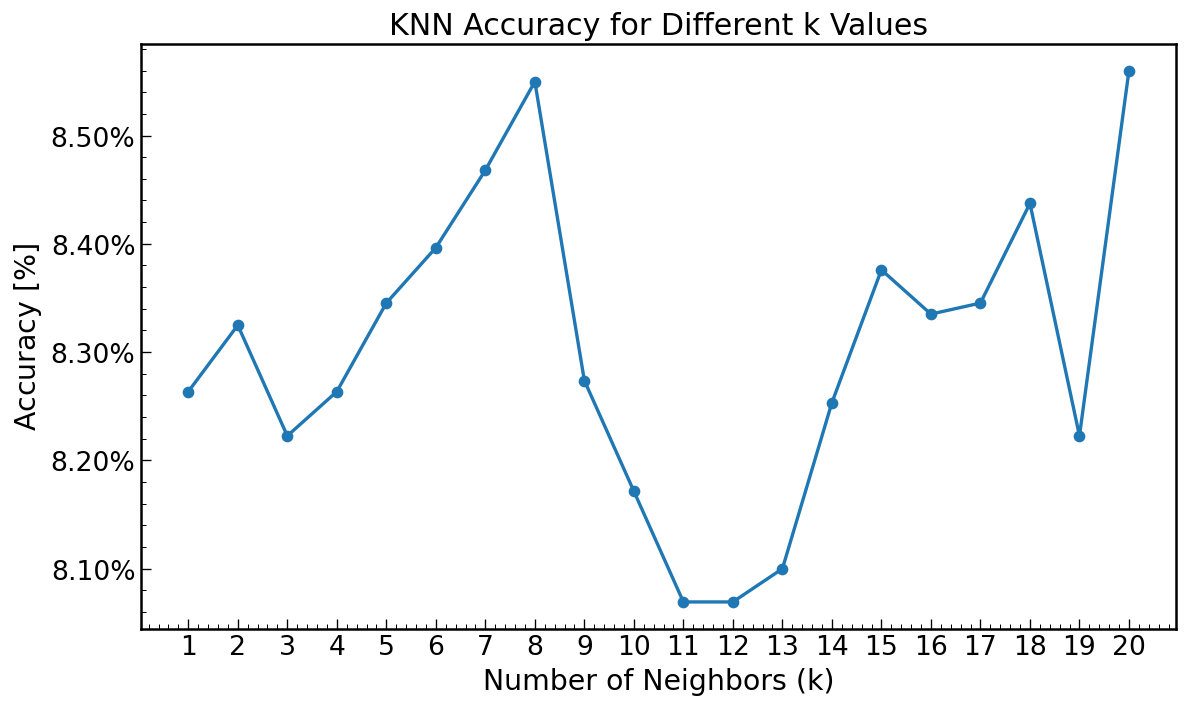

Best k value: 20 with accuracy: 0.0856 (8.6%)


In [52]:
# let's tune k
from matplotlib.ticker import PercentFormatter

k_values = range(1, 21)
k_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred_k = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred_k)
    k_accuracies.append(acc)
    
# plot accuracy vs k
plt.figure(figsize=(10, 6))
plt.plot(k_values, k_accuracies, marker='o')
plt.title('KNN Accuracy for Different k Values')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel(r'Accuracy [$\%$]')
plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=1))
plt.xticks(k_values)
plt.tight_layout()
plt.show()


# print best k value
best_k = k_values[k_accuracies.index(max(k_accuracies))]
print(f"Best k value: {best_k} with accuracy: {max(k_accuracies):.4f} ({max(k_accuracies)*100:.1f}%)")

### Notes

Best K is 20 but the accuracy is only 8.6% while for K = 5 it was 8.3%. Not much difference.  Accuracy also jumps around and is not smooth. This suggests that there is no real pattern to the data here. There are no correlations between lifestyle features and zodiac signs.

In [53]:
# retraom k with the best k value
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train, y_train)
y_pred_best = knn_best.predict(X_test)
knn_best_accuracy = accuracy_score(y_test, y_pred_best)
print(f"KNN Accuracy with best k={best_k}: {knn_best_accuracy:.4f} ({knn_best_accuracy*100:.1f}%)")

KNN Accuracy with best k=20: 0.0856 (8.6%)


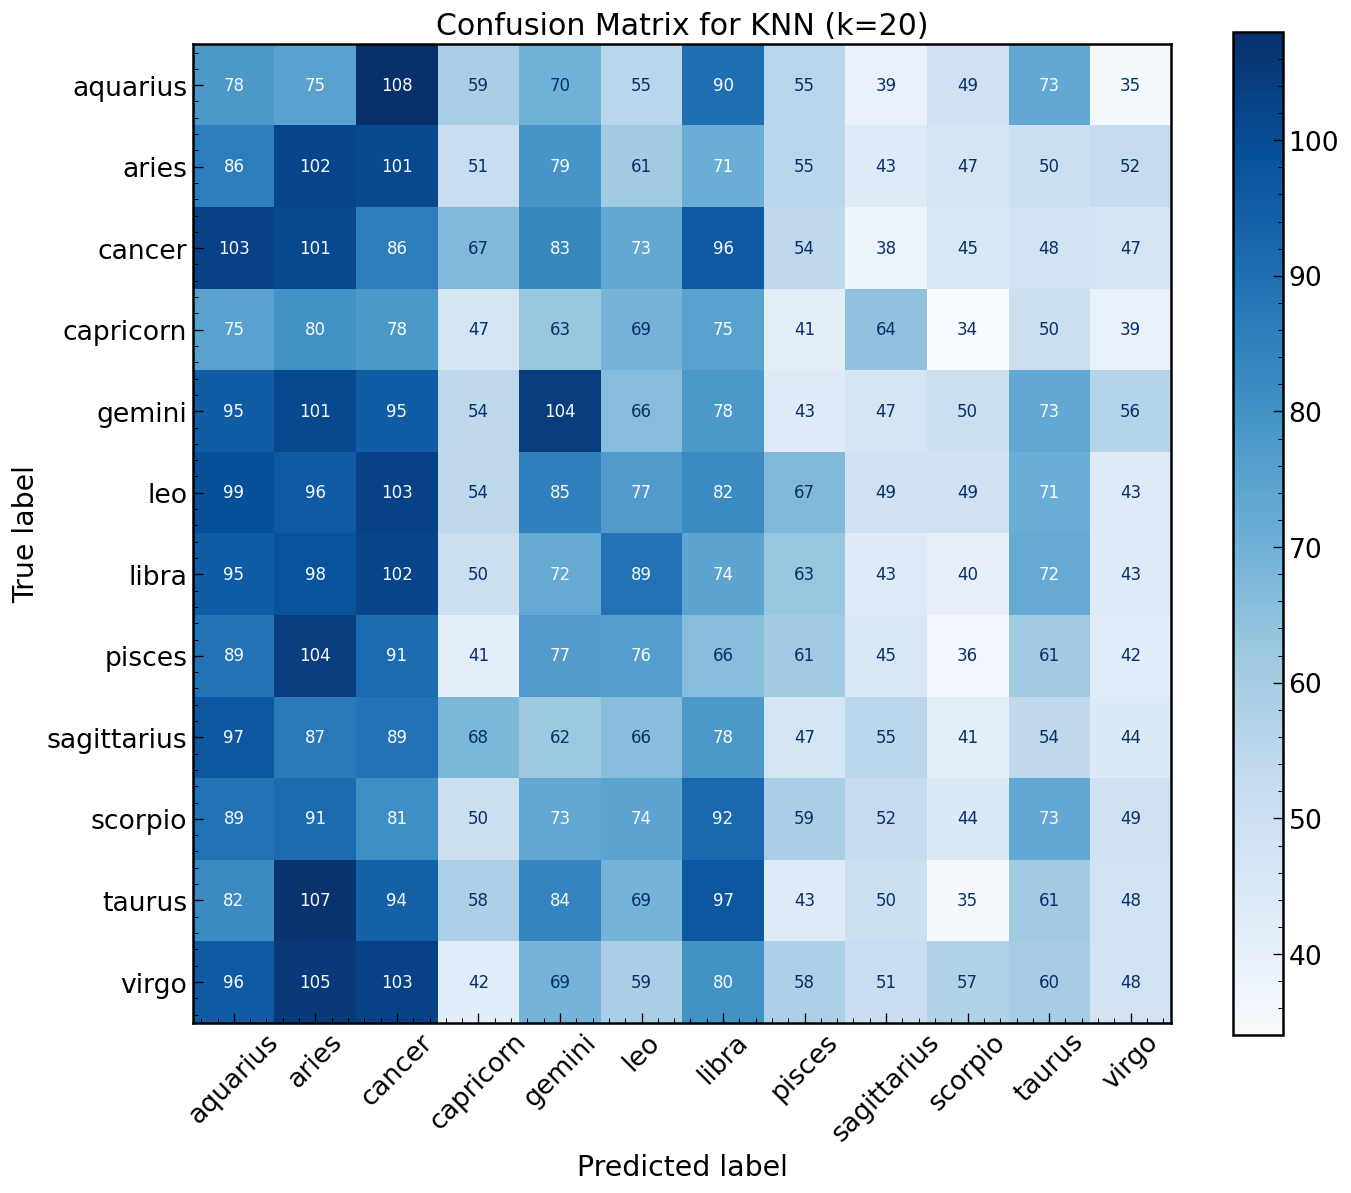

In [55]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# confusion matrix for zodiac sign predictions
cm = confusion_matrix(y_test, y_pred_best, labels=knn_best.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn_best.classes_)

plt.figure(figsize=(12, 10))
disp.plot(cmap=plt.cm.Blues, values_format='d', ax=plt.gca())
plt.title(f'Confusion Matrix for KNN (k={best_k})')
plt.xticks(rotation=45)   
plt.tight_layout()
plt.show()  

predications are random.

In [56]:
from sklearn.metrics import classification_report

# show precision, recall, f1-score for each zodiac sign
# precision: of all the instances predicted as a given sign, how many were actually that sign?
# recall: of all the instances that are actually a given sign, how many were predicted as that sign?
# f1-score: the harmonic mean of precision and recall, providing a single metric that balances both concerns. A high f1-score indicates that the model has both high precision and high recall for that sign.

class_report = classification_report(y_test, y_pred_best, target_names=knn_best.classes_)
print(f"Classification Report for KNN (k={best_k}):\n{class_report}")


Classification Report for KNN (k=20):
              precision    recall  f1-score   support

    aquarius       0.07      0.10      0.08       786
       aries       0.09      0.13      0.10       798
      cancer       0.08      0.10      0.09       841
   capricorn       0.07      0.07      0.07       715
      gemini       0.11      0.12      0.12       862
         leo       0.09      0.09      0.09       875
       libra       0.08      0.09      0.08       841
      pisces       0.09      0.08      0.09       789
 sagittarius       0.10      0.07      0.08       788
     scorpio       0.08      0.05      0.06       827
      taurus       0.08      0.07      0.08       828
       virgo       0.09      0.06      0.07       828

    accuracy                           0.09      9778
   macro avg       0.09      0.09      0.08      9778
weighted avg       0.09      0.09      0.08      9778



### KNN Results

After exploring KNN with a range of k values, the best accuracy that could be achieved was 8.6% with k=20. This is only slightly better than randomly guessing someone's zodiac sign (1/12 = 8.3%). It's not that surprising given that lifestyle choices do no exactly influence zodiac signs. Zodiac signs are tied to birthdates.

I also computed a confusion matrix to evaluate the accuracy of the classification. My confusion matrix does not look like how the confusion matrix of a well perfoming ML model would look. Some zodiac signs are just more over predicted than others. This tells me that the model is just guessin.

I also computed a classification report to show the metrics. Precision, recall, and F1 scores are all around 0.09 for every sign. This seems to indicate geussing. In terms of F1 scores, Gemini has the best score at 0.12 while Scorpio, Virgo, and Capricorn had the worst scores at 0.06-0.07. Those latter three were the hardest to predict.

It becomes immediately apparent that KNN is not the best ML model to use for this type of problem. These lifestyle choices do not have a correlation on zodiac sign (which is what I thought from the beginning).

## Support Vector Machine (SVM)

In [58]:
# training SVM model wtih RBF kernel because we have non-linear relationships
svm_rbf = SVC(kernel='rbf', C=1, random_state=42)

# fit the SVM model to the training data
svm_rbf.fit(X_train, y_train)   

# predict on the test set
y_pred_svm = svm_rbf.predict(X_test)

# calculate accuracy
svm_accuracy = accuracy_score(y_test, y_pred_svm)
print(f"SVM Accuracy with RBF kernel: {svm_accuracy:.4f} ({svm_accuracy*100:.1f}%)")    
print(f"KNN Accuracy with best k={best_k}: {knn_best_accuracy:.4f} ({knn_best_accuracy*100:.1f}%)")

SVM Accuracy with RBF kernel: 0.0933 (9.3%)
KNN Accuracy with best k=20: 0.0856 (8.6%)


In [ ]:
# range of C values to control how much we penalize misclassifications
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
C_accuracies = []

for c in C_values:
    svm = SVC(kernel='rbf', C=c, random_state=42)
    svm.fit(X_train, y_train)
    y_pred_c = svm.predict(X_test)
    acc = accuracy_score(y_test, y_pred_c)
    C_accuracies.append(acc)   
    print(f"SVM Accuracy with RBF kernel and C={c}: {acc:.4f} ({acc*100:.1f}%)") 
    

# plot the results
plt.figure(figsize=(10, 5))
plt.plot(C_values, C_accuracies, marker='o')
plt.xscale('log') 
plt.xlabel('C (regularization parameter)')
plt.ylabel('Accuracy (%)')
plt.title('SVM Accuracy for Different C Values')
plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=1))
plt.legend()
plt.tight_layout()
plt.show()

# print the best C
best_c = C_values[C_accuracies.index(max(C_accuracies))]
print(f"\nBest C: {best_c} with accuracy: {max(C_accuracies)*100:.1f}%")